## Data plotting notebook for landfill fire pollution

Takes data measured by F-450 equipped by [TFPM02](https://github.com/ThunderFly-aerospace/TFPM02) sensor.


In [4]:
import pyulog
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['figure.figsize'] = [20, 10]

### Measurement Description


### Conclusion



In [22]:
data2_ulog = pyulog.ULog("2025-04-22/14_41_17.ulg")
data1_ulog = pyulog.ULog("2025-04-22/14_06_57.ulg")

In [23]:
def plot_multiple_polar_wind_hodograph(datasets, labels, markers, title="Polar Wind Hodograph", step=10):
    plt.figure(figsize=(10, 10))
    ax = plt.subplot(111, polar=True)
    
    from matplotlib.lines import Line2D

    custom_legend = [
        Line2D([0], [0], marker=m, color='none', label=lbl,
               markerfacecolor=plt.cm.viridis(0.5), markersize=10)
        for m, lbl in zip(markers, labels)
    ]
    
    all_heights = np.concatenate([ds['vehicle_local_position/z'] for ds in datasets])
    vmin, vmax = np.nanmin(all_heights), np.nanmax(all_heights)

    scatter_plots = []
    for ds, label, marker in zip(datasets, labels, markers):
        speed = ds['wind_spd'][::step]
        direction_rad = np.radians(ds['wind_dir'][::step])
        height = ds['vehicle_local_position/z'][::step]

        sc = ax.scatter(
            direction_rad, speed, c=height, cmap='viridis',
            vmin=vmin, vmax=vmax, s=50, marker=marker, alpha=0.8, label=label
        )
        scatter_plots.append(sc)

    cbar = plt.colorbar(scatter_plots[0], ax=ax, label="AGL [m]")
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.legend(scatterpoints=1)
    ax.set_title(title)
    ax.text(np.radians(160), ax.get_rmax() * 1.15, "Wind speed [m/s]", ha='center', va='bottom', fontsize=12)
    ax.legend(handles=custom_legend, loc='upper right')
    plt.show()


In [32]:
def gen_df(data, fields):
    tables = []
    for field in fields:
        pr = field+'/'
        d = pd.DataFrame(data.get_dataset(field).data).set_index('timestamp').sort_index()
        d = d.add_prefix(pr).rename(columns={pr+'timestamp':'timestamp'})
        tables.append(d)
    
    return pd.concat(tables, sort=True).sort_index().interpolate(method="linear")

#data_mes = gen_df(data_ulog, ['sensor_airborne_particles', 'vehicle_local_position', 'vehicle_global_position', 'wind'])
data_mes = gen_df(data2_ulog, ['sensor_airborne_particles', 'vehicle_local_position', 'vehicle_global_position', 'sensor_hygrometer'])


for ds in [data_mes]:
    ds['vehicle_local_position/z'] *= -1
#    ds['wind_spd'] = np.sqrt(ds['wind/windspeed_north']**2 + ds['wind/windspeed_east']**2)
#    ds['wind_dir'] = (np.degrees(np.arctan2(ds['wind/windspeed_east'], ds['wind/windspeed_north'])) + 360) % 360

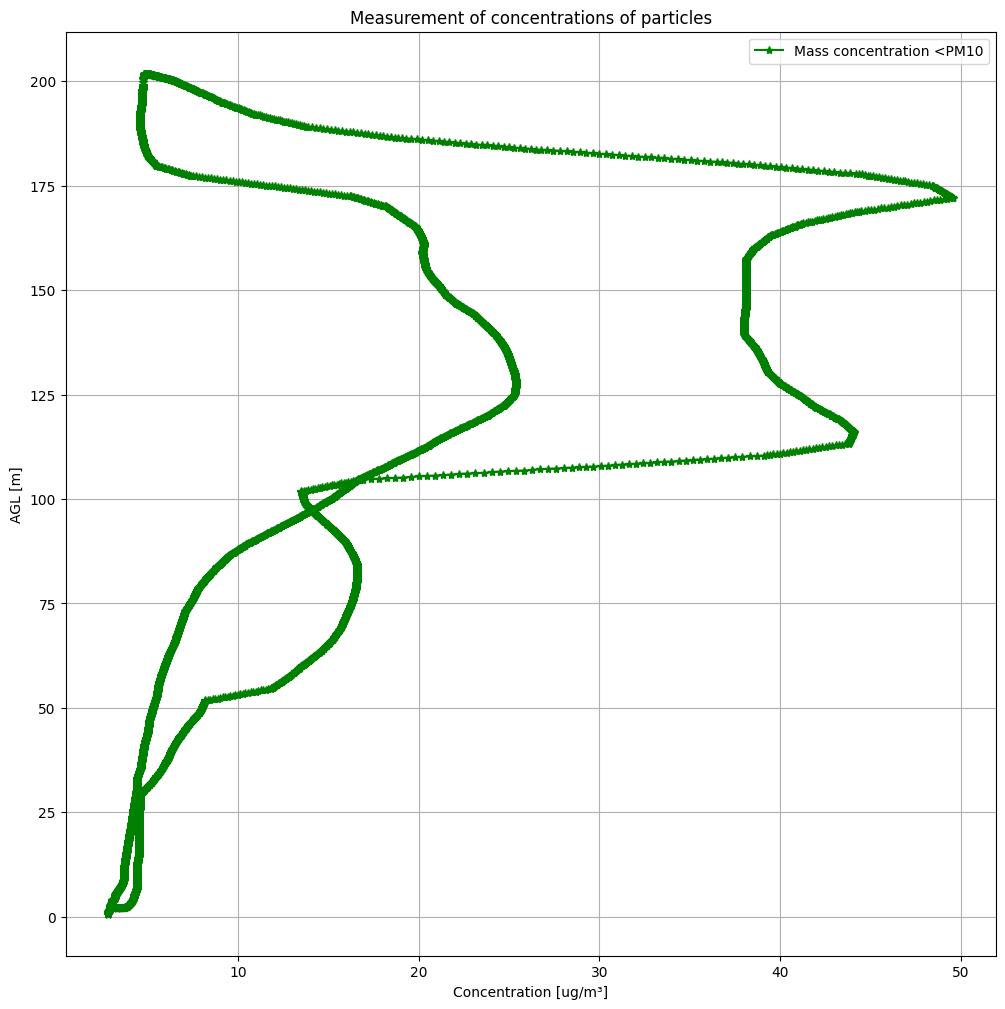

In [47]:
plt.figure(figsize=(12, 12))

plt.plot(data_mes['sensor_airborne_particles/mass_concentration_pm10_0'], data_mes['vehicle_local_position/z'], color="green", marker="*", ls='-', label="Mass concentration <PM10")


plt.ylabel("AGL [m]")
plt.xlabel("Concentration [ug/m³]")
#plt.xlim(0,15)
#plt.ylim(0, 350)
plt.title("Measurement of concentrations of particles")
plt.grid()
plt.legend()

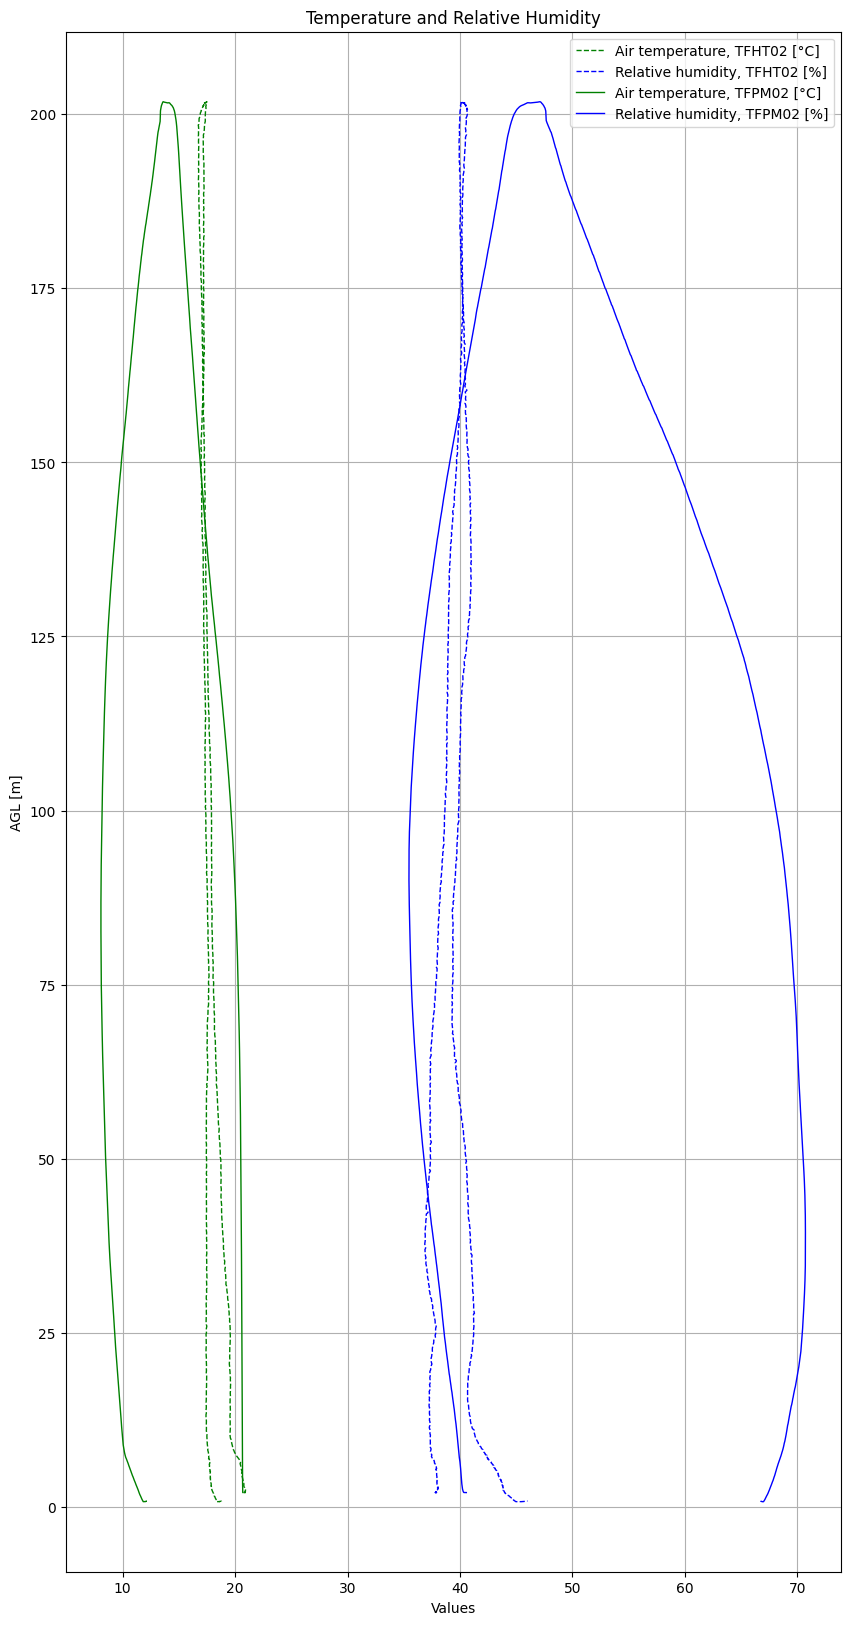

In [48]:
plt.figure(figsize=(10, 20))

plt.plot(data_mes['sensor_hygrometer/temperature'], data_mes['vehicle_local_position/z'], color="green", ls='--', lw=1, label="Air temperature, TFHT02 [°C]")
plt.plot(data_mes['sensor_hygrometer/humidity'], data_mes['vehicle_local_position/z'], color="blue", ls='--', lw=1, label="Relative humidity, TFHT02 [%]")
plt.plot(data_mes['sensor_airborne_particles/temperature'], data_mes['vehicle_local_position/z'], color="green", ls='-', lw=1, label="Air temperature, TFPM02 [°C]")
plt.plot(data_mes['sensor_airborne_particles/relative_humidity'], data_mes['vehicle_local_position/z'], color="blue", ls='-', lw=1, label="Relative humidity, TFPM02 [%]")



plt.ylabel("AGL [m]")
plt.xlabel("Values")
#plt.xlim(0,15)
#plt.ylim(0, 350)
plt.title("Temperature and Relative Humidity")
plt.grid()
plt.legend()

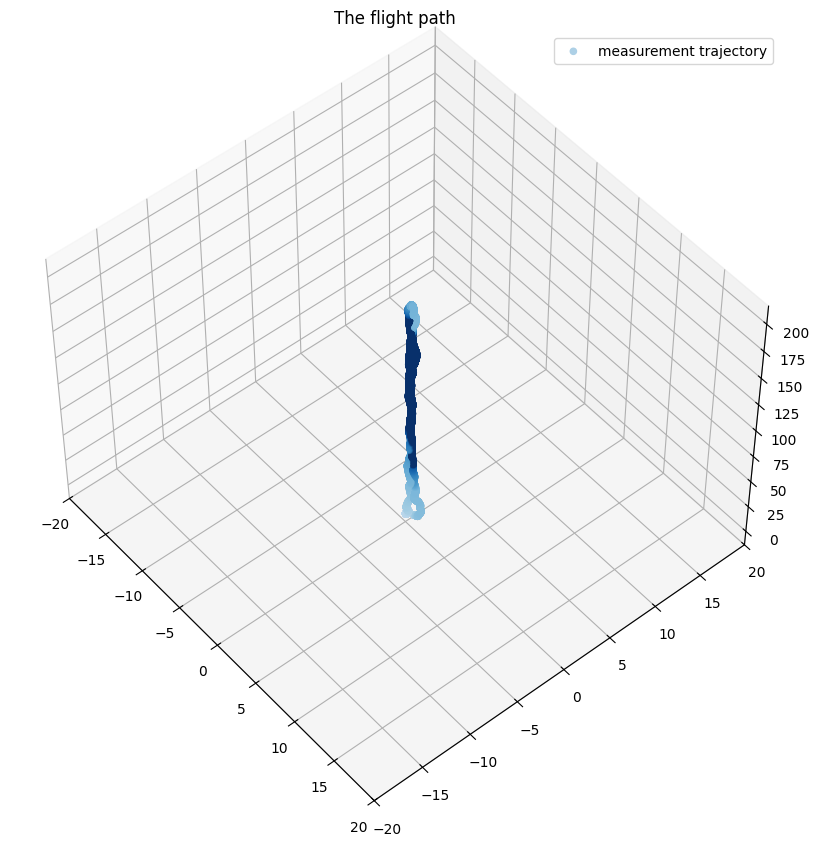

In [50]:
from mpl_toolkits import mplot3d
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection='3d')
ax.scatter3D(data_mes['vehicle_local_position/x'], data_mes['vehicle_local_position/y'], data_mes['vehicle_local_position/z'], c=data_mes['sensor_airborne_particles/mass_concentration_pm10_0'], cmap='Blues', vmin=0, vmax=10, label="measurement trajectory")
ax.view_init(50, -40)
plt.legend()
plt.xlim(-20,20)
plt.ylim(-20, 20)
plt.title("The flight path")
plt.grid()